In [1]:
%cd ../

/home/melanie/PycharmProjects/RedundantPrefrontalHemispheres


In [2]:
import matplotlib.pyplot as plt
plt.style.use("stylefile.mplstyle")


# Define colors
colors = {
    "Single": "#333333",
    "Left": "#2C7BB6",
    "Right": "#D7191C",
    "Ipsilateral": "#4477AA",
    "Contralateral": "#BB5544",
    "Within": "#1f3a63ff",
    "Across": "#e89d0bff"
}

from matplotlib.colors import LinearSegmentedColormap
left_right_cmap = LinearSegmentedColormap.from_list("LeftRight",\
                                                     [colors['Left'], "white", colors['Right']])
ipsi_contra_cmap = LinearSegmentedColormap.from_list("IpsiContra",\
                                                     [colors['Ipsilateral'], "white", colors['Contralateral']])

In [3]:
## circstats
def len2(x):
	if type(x) is not type([]):
		if type(x) is not type(array([])):
			return -1
	return len(x)

def phase2(x):
	if not np.isnan(x):
		return phase(x)
	return nan
    
def circdist(angles1,angles2):
    ''' calculates circular distance of angles [rad]'''
    if len2(angles2) < 0:
        if len2(angles1) > 0:
            angles2 = [angles2]*len(angles1)
        else:
            angles2 = [angles2]
            angles1 = [angles1]
        if len2(angles1) < 0:
            angles1 = [angles1]*len(angles2)
    return array(list(map(lambda a1,a2: phase2(np.exp(1j*a1)/np.exp(1j*a2)), angles1,angles2)))

In [4]:
def sig_bar(sigs,axis,y,ax,color):
	w=np.diff(axis)[0]
	for s in sigs:
		beg =axis[s]-w/2
		end = axis[s]+w/2
		ax.fill_between([beg,end],[y[0],y[0]],[y[1],y[1]],color=color)

In [5]:
def sign_rl(rel_loc):
    # returns sign of array unless value=0, returns 1
    sign = [np.sign(rel_loc[rl]) if rel_loc[rl]!=0.0 else 1 for rl in range(len(rel_loc))]
    return np.array(sign)

# LOAD DATA

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.io import loadmat
from scipy.stats import *
from scipy.optimize import curve_fit
from cmath import phase
from numpy import array
from scipy.sparse import csr_matrix
import urllib
import pickle
from scipy.io import loadmat
import glob
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
#from pymicro.view.vol_utils import compute_affine_transform
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
import statsmodels.formula.api as sf
from sklearn import metrics
from random import randint
from numpy.linalg import inv
import math
import io
#import h5py
from circ_stats import *
from patsy import dmatrices
import statsmodels.api as sm
import helpers as hf
import statsmodels.formula.api as smf
import copy
import matplotlib.ticker as ticker
from pingouin import circ_corrcc

#with open('./Results_Full/df_serial.pickle', 'rb') as handle:
with open('./Results/df_serial_Sa0.pickle', 'rb') as handle:
    df_sb = pickle.load(handle)
df_sb = df_sb.reset_index(drop=True)
df_sb.rel_loc = np.round(df_sb.rel_loc,3)

monkeys = df_sb.monkey.unique()

    
#df_behav = df_behav.loc[(df_behav.monkey=='Sa') | (df_behav.monkey=='Wa')].reset_index(drop=True)
df_sb['session_continuous'] = [df_sb.monkey[i]+str(df_sb.session[i]) for i in df_sb.index]

same_id = 1
opp_id = 0
border_id = 2

# colors for accuracy plots
cmap_ACC = matplotlib.cm.get_cmap('summer_r')
colors_ACC = [cmap_ACC(0.1+i/(3+1)) for i in range(3)]

# colors for delay dependence plots
cmap_delay = matplotlib.cm.get_cmap('binary_r')
colors_delay = [cmap_delay(i/(4+0.1)) for i in range(4)]

# colors for serial dependence plots
# cmap_SD = matplotlib.cm.get_cmap('Oranges_r')
# colors_SD = [cmap_SD(0.1+i/(3+1)) for i in range(3)]
colors_SD = ['#054E3A', '#43AA8B', '#859F98']

cmap = matplotlib.cm.get_cmap('binary_r')
colors_mono_bw = [cmap((m+1)/3.8) for m in range(3)]

# colors for same vs opposite hemisphere
colors_so = {'within': 'darkgreen', 'across': 'darkorange'}

cmap = matplotlib.cm.get_cmap('PiYG')
color1=cmap(230)#'#751A5D'#'#873145'
color2=cmap(40)#'#0C7C59'#'#2A7979'
colors_ic={'ipsi':color2, 'contra':color1}

# DEFINE DOG FIT PARAMETERS FOR EACH ANIMAL (based on BIC, questionable for Pe, Wa (delta BIC <2)
sigma={'Sa':0.9, 'Pe':2.15, 'Wa':0.45}
neural_sigma = {'Sa': 1.35, 'Pe': 3.0, 'Wa': 1.75}#
reactivation_sigma={'Sa':2.6, 'Pe':1.45, 'Wa':1.35}

In [20]:
df_sb.keys()

Index(['trial_id', 'target_prev', 'target_xy_prev', 'response_prev',
       'response_prev_uncorrected', 'err_prev', 'err_prev_uncorrected',
       'response_xy_prev', 'response_xy_prev_uncorrected', 'delay_prev',
       'target_curr', 'target_xy_curr', 'response_curr',
       'response_curr_uncorrected', 'response_xy_curr',
       'response_xy_curr_uncorrected', 'err', 'err_uncorrected', 'rel_loc',
       'delay_curr', 'ITI', 'ITI_prev', 'broke', 'hemifield_prev',
       'hemifield_curr', 'topdown_prev', 'topdown_curr', 'monkey', 'session',
       'num_targ', 'session_continuous'],
      dtype='object')

----

# General information

In [21]:
for targ in [4, 8, 16]:
    print('Targets = '+str(targ)+', '+\
          str(len(df_sb[df_sb.num_targ==targ].session_continuous.unique()))+' sessions, '+\
         str(len(df_sb[df_sb.num_targ==targ]))+' trials.')


Targets = 4, 7 sessions, 3453 trials.
Targets = 8, 12 sessions, 5666 trials.
Targets = 16, 22 sessions, 9065 trials.


# Fig 1: Accuracy

### Fig 1d: delay dependence of accuracy

In [22]:
# use 8 targets
# only use 8 targets in specific locaton to get clean plot
sess0 = df_sb.loc[(df_sb.monkey=='Sa') & (df_sb.session==0)]
target_tuples = [tuple(np.round(sess0.target_xy_curr[i],0)) for i in sess0.index]
chosen_targs = list(set(target_tuples))

# define colors (need offset, otherwise one color is white)
target_colors = [cmap_ACC(-0.45+i/(len(chosen_targs)-2)) for i in range(len(chosen_targs))]
# left from bottom to top, borders, right from bottom to top
target_hue_order = [ 1.5708, -1.5708, -0.7854 ,  0.     , 0.7854,  -2.35619, 3.14159, 2.35619]
# set border trial colors to grey
target_colors[0] = 'grey'
target_colors[1] = 'grey'

# convert coordinates to tuples
df_sb['targ_curr_tuple'] = [tuple(np.round(df_sb.target_xy_curr[i],0))\
                                         for i in df_sb.index]

# only use trials with targets in the chosen locations
df_chosen = df_sb.loc[np.where([(df_sb.targ_curr_tuple[i] in chosen_targs)\
                                             for i in df_sb.index])[0]].copy().reset_index(drop=True)

Delay lengths split based on quartile delays = 2120.0s, 2420.0s.


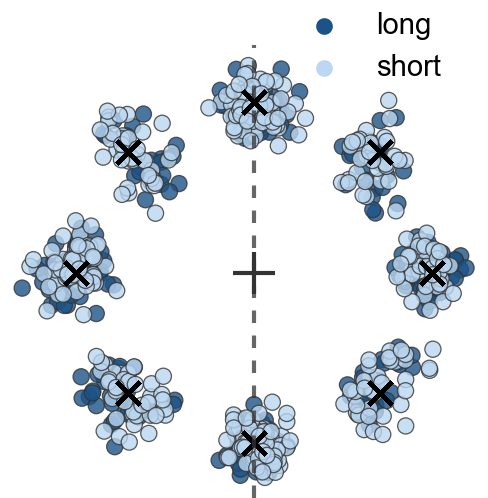

In [23]:
df_chosen['response_x_uncorrected'] = [df_chosen.response_xy_curr_uncorrected[i][0] for i in df_chosen.index]
df_chosen['response_y_uncorrected'] = [df_chosen.response_xy_curr_uncorrected[i][1] for i in df_chosen.index]

print('Delay lengths split based on quartile delays = '+str(np.percentile(df_chosen.delay_curr, 25))+'s, '+\
     str(np.percentile(df_chosen.delay_curr, 75))+'s.')
df_chosen['delay'] = ['long' if delay > np.percentile(df_chosen.delay_curr, 75)\
                        else 'short' if delay < np.percentile(df_chosen.delay_curr, 25)\
                      else 'middle half' for delay in df_chosen.delay_curr.values]

df_longshortquart = df_chosen.drop(index = np.where(df_chosen.delay == 'middle half')[0])
delay_hue_order = ['long', 'short']

delay_colors = ['#1C5387', '#BBD7F1']#[colors_delay[0], colors_delay[3]]
#delay_colors = ['#333333', 'w']#[colors_delay[0], colors_delay[3]]

test = df_longshortquart.copy()
test = test.sort_values('delay', key=np.vectorize(delay_hue_order.index))

# plot the figure
f, ax = plt.subplots(figsize=(2.1,2))
plt.scatter(0, 0, color='#333333', marker='+', s=100)
plt.axvline(0, color='#333333', dashes=[3,3], alpha=0.75, linewidth=1)
# plot responses
g = sns.scatterplot(data=test, x='response_x_uncorrected', y='response_y_uncorrected', hue='delay',\
                palette=delay_colors, hue_order = delay_hue_order, alpha=0.8, s=15,ec='#333333')
g.legend_.set_title(None)
g.legend(bbox_to_anchor=(0.58, 1.1), loc='upper left', borderaxespad=0)
# plot targets
plt.scatter([df_longshortquart.target_xy_curr[i][0] for i in df_longshortquart.index],\
               [df_longshortquart.target_xy_curr[i][1] for i in df_longshortquart.index], color='k', marker='x', s=30)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
#plt.savefig(DATAPATH+'/Figures/Paper/Behavior/DelayDistributedAccuracy.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### Fig 1e

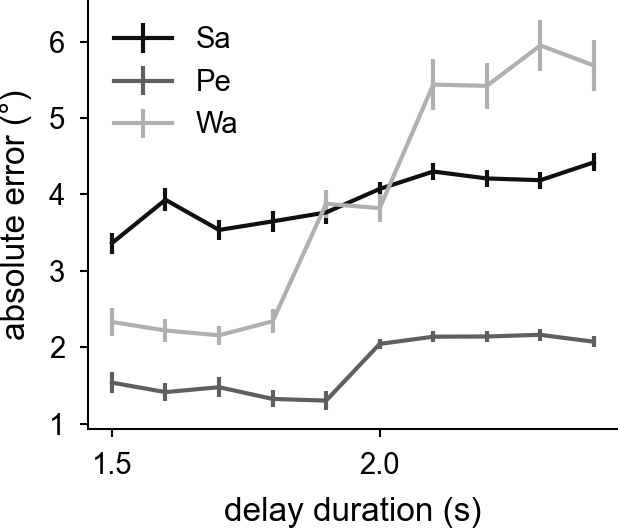

In [24]:
cmap = matplotlib.cm.get_cmap('binary_r')
colors_mono_bw = [cmap((m+0.2)/3.2) for m in range(3)]

df_helper = df_sb.copy()

df_helper['delay_prev_int'] = np.round(df_helper.delay_prev/1000, 1)
df_helper['abs_err'] = np.abs(df_helper.err)

f,ax = plt.subplots(1,1, figsize=(2.3,2))
for m, monkey in enumerate(monkeys):
    df_mono = df_helper.loc[df_helper.monkey==monkey]
    
    # group by delay length
    delay_group = df_mono.groupby('delay_prev_int')
    keys = np.array(list(delay_group.groups.keys()))
    
    # delays smaller 2.5s (afterwards STD goes up)
    index = np.where(keys<2.5)[0]
    
    #plt.scatter(df_mono.delay_prev_int, df_mono.abs_err, alpha=0.03, color=colors_mono_bw[m])
    
    plt.errorbar(keys[index], np.rad2deg(delay_group.abs_err.mean().values[index]),\
                 yerr=np.rad2deg(delay_group.abs_err.sem().values[index]), color=colors_mono_bw[m], label=monkey)
    
ax.set_xlabel('delay duration (s)')
ax.set_xticks([1.5, 2])
ax.set_ylabel('absolute error (°)')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.legend()
plt.tight_layout()
sns.despine()
#plt.savefig('./Figures/Figure1/DelayAccuracyReduction_Lineplot_smaller25s.svg')
plt.show()

Linear model across sessions (not mixed, since each session only has a 0.5s delay)

### Statistics Fig. 1e

In [25]:
df_sb['err_deg'] = np.rad2deg(df_sb.err)
df_sb['abs_err_deg'] = np.abs(df_sb.err_deg)
df_sb['delay_inSecs'] = np.round(df_sb.delay_curr/1000,1)

# group model
for m,mono in enumerate(monkeys): # enumerate(['Sa']):#
    df_mono = df_sb.loc[df_sb.monkey==mono].copy()
    print('################## ' + mono + ' ##################')
    M = smf.ols(formula='abs_err_deg~delay_inSecs',\
                    data=df_mono).fit()
    
    # reporting summary
    beta = M.params['delay_inSecs']
    se   = M.bse['delay_inSecs']
    tval = M.tvalues['delay_inSecs']
    pval = M.pvalues['delay_inSecs']
    ci_low, ci_high = M.conf_int().loc['delay_inSecs']
    N = int(M.nobs)

    print('beta = '+str(np.round(beta,2))+'°/s')
    print("95% CI ["+str(np.round(ci_low,2))+', '+str(np.round(ci_high,2))+']')
    print('t('+str(int(M.df_resid))+') = '+str(np.round(tval,2)))
    print('p = '+str("{:.2e}".format(pval)))
    print('# trials: '+str(len(df_mono))+', '+str(len(df_mono.session.unique()))+' sessions.')


#Mixed model does not work due to delay differences (each session covers 0.5 s)

################## Sa ##################
beta = 0.77°/s
95% CI [0.53, 1.0]
t(7902) = 6.31
p = 2.95e-10
# trials: 7904, 16 sessions.
################## Pe ##################
beta = 0.85°/s
95% CI [0.64, 1.06]
t(7632) = 8.07
p = 7.94e-16
# trials: 7634, 16 sessions.
################## Wa ##################
beta = 4.76°/s
95% CI [4.21, 5.31]
t(2644) = 16.95
p = 3.08e-61
# trials: 2646, 9 sessions.


### across monkeys

In [26]:
df_sb['err_deg'] = np.rad2deg(df_sb.err)
df_sb['abs_err_deg'] = np.abs(df_sb.err_deg)
df_sb['delay_inSecs'] = np.round(df_sb.delay_curr/1000,1)


M = smf.ols(formula='abs_err_deg~delay_inSecs',\
                data=df_sb).fit()

# reporting summary
beta = M.params['delay_inSecs']
se   = M.bse['delay_inSecs']
tval = M.tvalues['delay_inSecs']
pval = M.pvalues['delay_inSecs']
df   = int(M.df_resid)
ci_low, ci_high = M.conf_int().loc['delay_inSecs']
N = int(M.nobs)

print('beta = '+str(np.round(beta,2))+'°/s')
print("95% CI ["+str(np.round(ci_low,2))+', '+str(np.round(ci_high,2))+']')
print('t('+str(int(M.df_resid))+') = '+str(np.round(tval,2)))
print('p = '+str("{:.2e}".format(pval)))
print('# trials: '+str(len(df_sb))+', '+str(len(df_sb.session_continuous.unique()))+' sessions.')


#Mixed model does not work due to delay differences

beta = 0.63°/s
95% CI [0.46, 0.79]
t(18182) = 7.56
p = 4.38e-14
# trials: 18184, 41 sessions.


---

# Fig. 1f: Serial dependence

################## Sa ##################
beta = 2.42°
95% CI [2.23, 2.61]
t(7902) = 24.83
p = 4.05e-131
# trials: 7904, 16 sessions.
################## Pe ##################
beta = 0.06°
95% CI [-0.02, 0.14]
t(7632) = 1.4
p = 1.60e-01
# trials: 7634, 16 sessions.
################## Wa ##################
beta = 0.66°
95% CI [-0.02, 1.33]
t(2644) = 1.92
p = 5.54e-02
# trials: 2646, 9 sessions.


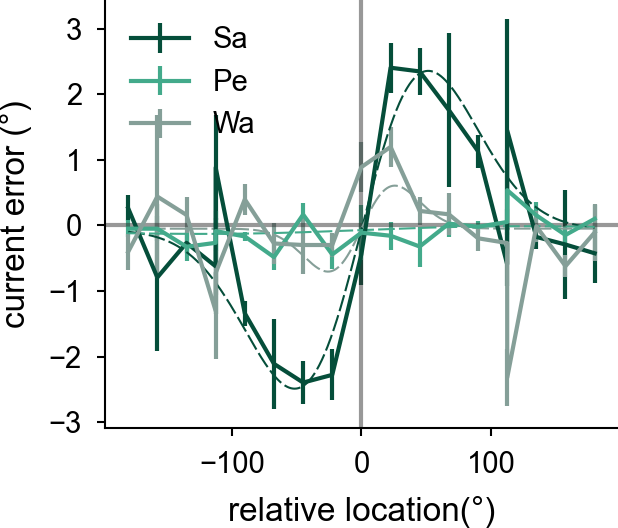

In [27]:
monkeys = ['Sa', 'Pe', 'Wa']
df_sb['rel_loc_roll'] = np.roll(df_sb.rel_loc,1)
df_sb['err_deg_uncorrected'] = np.rad2deg(df_sb.err_uncorrected)

fig,ax = plt.subplots(1,1,figsize=(2.3, 2))
plt.axhline(color='#333333', alpha=0.5, linewidth=1)
plt.axvline(color='#333333', alpha=0.5, linewidth=1)

targets = np.unique(df_sb.rel_loc)

for m,mono in enumerate(monkeys): # enumerate(['Sa']):#
    df_mono = df_sb.loc[df_sb.monkey==mono].copy()
    sb_session = np.empty((len(np.unique(df_mono.session)),len(targets)))
    for sess in np.unique(df_mono.session):
        df_sess = df_mono.loc[df_mono.session == sess]
        for t_id,t in enumerate(targets):
            sb_session[int(sess),t_id] = circmean(df_sess.loc[df_sess.rel_loc==t].err, low=-np.pi, high=np.pi)
            #except:
            #    sb_session[t_id] = np.nan
    ax.errorbar(np.rad2deg(targets),np.rad2deg(np.nanmean(sb_session, axis=0)),\
                yerr = np.rad2deg(sem(sb_session, axis=0, nan_policy='omit')),  color=colors_SD[m], label=mono)

    ax.spines['right'].set_visible(False)
    
    # FIT MODEL
    xx = np.linspace(-np.pi, np.pi, 1000)
    df_mono['DoG_fit'] = -hf.dog1(sigma[mono],df_mono.rel_loc)
    #M = smf.mixedlm(formula='err~DoG_fit', data=df_mono,\
    #               groups = df_mono['session']).fit()
    M = smf.ols(formula='err~DoG_fit', data=df_mono).fit()
    
    # reporting summary
    beta = M.params['DoG_fit']
    se   = M.bse['DoG_fit']
    tval = M.tvalues['DoG_fit']
    pval = M.pvalues['DoG_fit']
    df   = int(M.df_resid)
    ci_low, ci_high = M.conf_int().loc['DoG_fit']
    N = int(M.nobs)

    print('################## ' + mono + ' ##################')
    print('beta = '+str(np.round(np.rad2deg(beta),2))+'°')
    print("95% CI ["+str(np.round(np.rad2deg(ci_low),2))+', '+str(np.round(np.rad2deg(ci_high),2))+']')
    print('t('+str(int(M.df_resid))+') = '+str(np.round(tval,2)))
    print('p = '+str("{:.2e}".format(pval)))
    print('# trials: '+str(len(df_mono))+', '+str(len(df_mono.session.unique()))+' sessions.')

    #if mono=='Sa':
    plt.plot(np.rad2deg(xx),\
             np.rad2deg(M.params['Intercept']+M.params['DoG_fit']*-hf.dog1(sigma[mono], xx)),\
             color=colors_SD[m], dashes=[8,2], lw=0.5)


ax.spines['top'].set_visible(False)
plt.xlabel('relative location(°)')
plt.ylabel('current error (°)')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.legend()
plt.tight_layout()
#plt.savefig(DATAPATH+'/Figures/Paper/Behavior/SerialBiasSaPeWa.svg')

plt.show()

## Fig 1g: Delay dependent SD

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/linear_model.py:1650: RuntimeWarning: invalid value encountered in double_scalars
  return np.dot(wresid, wresid) / self.df_resid


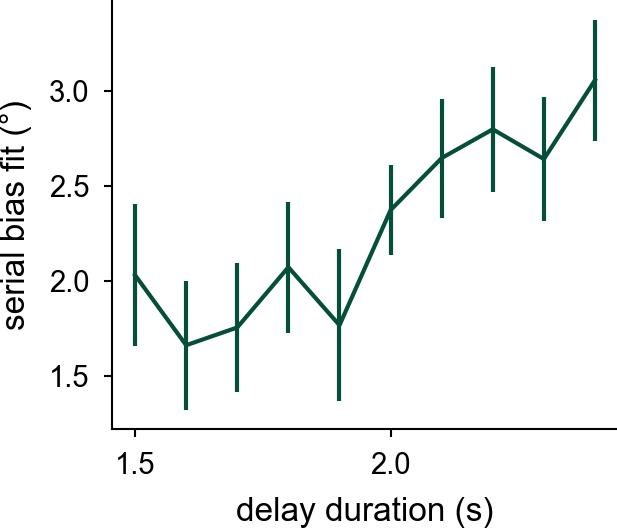

In [28]:
fig,ax = plt.subplots(1,1,figsize=(2.3,2))
#ax.axhline(color='#333333', linewidth=1, alpha=0.5)
    
for m,monkey in enumerate(monkeys):
    df_mono = df_sb.loc[df_sb.monkey==monkey].copy()
    df_mono['delay_curr_round'] = np.round(df_mono.delay_curr/1000,1)

    # choose what to split by
    chosen_factor = 'delay_curr_round'#'ITI'#'delay_curr'#'trial_id'#
    
    dog_fits = {d: np.nan for d in np.unique(df_mono[chosen_factor])}
    dog_fits_sem = {d: np.nan for d in np.unique(df_mono[chosen_factor])}
    dog_fits_p = {d: np.nan for d in np.unique(df_mono[chosen_factor])}
    # for each delay compute the serial dependence strength
    for idx_delay,(delay_i, df_delay) in enumerate(df_mono.groupby(chosen_factor)):
        df_delay['DoG_fit'] = -hf.dog1(sigma[monkey], df_delay.rel_loc.values)
        M = smf.ols("err ~ DoG_fit", data = df_delay).fit()
        dog_fits[delay_i] = M.params['DoG_fit']
        dog_fits_sem[delay_i] = M.bse['DoG_fit']
        dog_fits_p[delay_i] = M.pvalues['DoG_fit']

    delays = np.array(list(dog_fits.keys()))
    chosendelays = np.where(delays < 2.5)[0]
    delays = delays[chosendelays]
    fits = np.array(list(dog_fits.values()))[chosendelays]
    SEM = np.array(list(dog_fits_sem.values()))[chosendelays]
    pvals = np.array(list(dog_fits_p.values()))[chosendelays]
    if monkey == 'Sa':
        ax.errorbar(delays, np.rad2deg(fits), \
                    yerr = np.rad2deg(SEM),\
                    color=colors_SD[m], label=monkey)
        nonsig = np.where(pvals>0.05)[0]
        ax.scatter(delays[nonsig], np.rad2deg(fits)[nonsig], marker='o', color='grey')

ax.set_xticks([1.5, 2.])
ax.set_xlabel('delay duration (s)')
ax.set_ylabel('serial bias fit (°)')
#plt.legend()
#plt.ylim([-1.75,4.25])
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.tight_layout()
sns.despine()
#plt.savefig('./Figures/Figure1/DelaySerialBias_timeresolved.svg')
plt.show()


---

In [29]:
for monkey in monkeys:
    df_mono = df_sb.loc[df_sb.monkey==monkey].copy()
    df_mono['delay_curr_round_inSecs'] = np.round(df_mono.delay_curr/1000,1)
    targets = np.unique(df_mono.loc[df_mono.session==0].rel_loc)#np.unique(df_mono.rel_loc)

    df_mono['DoG_fit'] = -hf.dog1(sigma[monkey], df_mono.rel_loc)
    M = smf.ols('err ~ DoG_fit*delay_curr_round_inSecs', data = df_mono).fit()

    # reporting summary
    beta = M.params['DoG_fit:delay_curr_round_inSecs']
    se   = M.bse['DoG_fit:delay_curr_round_inSecs']
    tval = M.tvalues['DoG_fit:delay_curr_round_inSecs']
    pval = M.pvalues['DoG_fit:delay_curr_round_inSecs']
    df   = int(M.df_resid)
    ci_low, ci_high = M.conf_int().loc['DoG_fit:delay_curr_round_inSecs']
    N = int(M.nobs)

    print('################## ' + monkey + ' ##################')
    print('beta = '+str(np.round(np.rad2deg(beta),2))+'°/s')
    print("95% CI ["+str(np.round(np.rad2deg(ci_low),2))+', '+str(np.round(np.rad2deg(ci_high),2))+']')
    print('t('+str(int(M.df_resid))+') = '+str(np.round(tval,2)))
    print('p = '+str("{:.2e}".format(pval)))
    print('# trials: '+str(len(df_mono))+', '+str(len(df_mono.session.unique()))+' sessions.')



################## Sa ##################
beta = 1.03°/s
95% CI [0.41, 1.65]
t(7900) = 3.26
p = 1.11e-03
# trials: 7904, 16 sessions.
################## Pe ##################
beta = 0.22°/s
95% CI [-0.12, 0.55]
t(7630) = 1.28
p = 2.02e-01
# trials: 7634, 16 sessions.
################## Wa ##################
beta = 0.06°/s
95% CI [-3.17, 3.29]
t(2642) = 0.03
p = 9.73e-01
# trials: 2646, 9 sessions.


# Supplement:

### Left vs right hemifield precision

Left - Right MAE paired: t(40) = -1.07, p = 2.91e-01, mean = -0.08, 95% CI [-0.22,0.07]


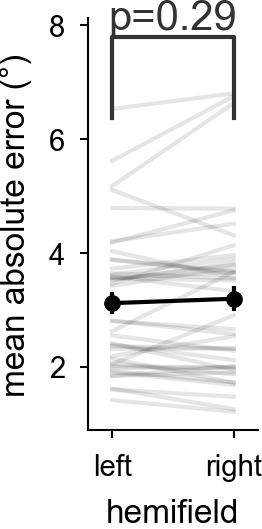

In [30]:
from scipy.stats import t

mae = []
mae_left = []
mae_right = []
for sess in df_sb.session_continuous.unique():
    df_sess = df_sb.loc[df_sb.session_continuous == sess]
    
    df_left = df_sess.loc[(df_sess.target_prev > -np.pi/2) & (df_sess.target_prev < np.pi/2)]
    df_right = df_sess.loc[(df_sess.target_prev > np.pi/2) | (df_sess.target_prev < -np.pi/2)]
        
    mae.append(np.rad2deg(np.mean(np.abs(df_sess.err))))
    mae_left.append(np.rad2deg(np.mean(np.abs(df_left.err))))
    mae_right.append(np.rad2deg(np.mean(np.abs(df_right.err))))

f, ax = plt.subplots(figsize=(1.1, 2))
ax.plot([np.zeros((len(mae_left))), np.ones((len(mae_right)))],\
           [mae_left, mae_right], color='k', alpha=0.1);
ax.errorbar([0, 1], [np.mean(mae_left), np.mean(mae_right)],\
             yerr = [sem(mae_left), sem(mae_right)], marker='o', color='k')
# significance
pval = np.round(ttest_rel(mae_left, mae_right)[1], 2)
y0,y1 = ax.get_ylim()
ax.plot([0,0,1,1],\
        [y1-1*y1/10,y1+y1/10, y1+y1/10, y1-1*y1/10], linewidth=1, color='#333333')
ax.annotate('p='+str(pval),\
           (0.5, y1+y1/10), ha='center', va='bottom', fontsize=10, color='#333333')
ax.set_xticks([0,1])
ax.set_xlim([-0.2, 1.2])
ax.set_xticklabels(['left', 'right'])
ax.set_xlabel('hemifield')
ax.set_ylabel('mean absolute error (°)')
plt.tight_layout()
#plt.savefig(DATAPATH+'/Figures/Paper/Behavior/Supplement_LeftRightAccuracy.svg', bbox_inches='tight', pad_inches=0)


# REPORTING SUMMARY
mae_right = np.array(mae_right)
degf = len(mae_right) - 1
test, pval = ttest_rel(mae_left, mae_right)
mean_x = np.mean(mae_left - mae_right)
se = stats.sem(mae_left - mae_right)  # standard error of the mean
ci_low, ci_high = t.interval(0.95, degf, loc=mean_x, scale=se)
print('Left - Right MAE paired: t('+str(degf)+') = '+str(np.round(test, 2))+', p = '+"{:.2e}".format(pval)+\
     ", mean = "+str(np.round(mean_x,2))+\
      ", 95% CI ["+str(np.round(ci_low,2))+","+str(np.round(ci_high, 2))+"]")

### Left vs. right serial dependence

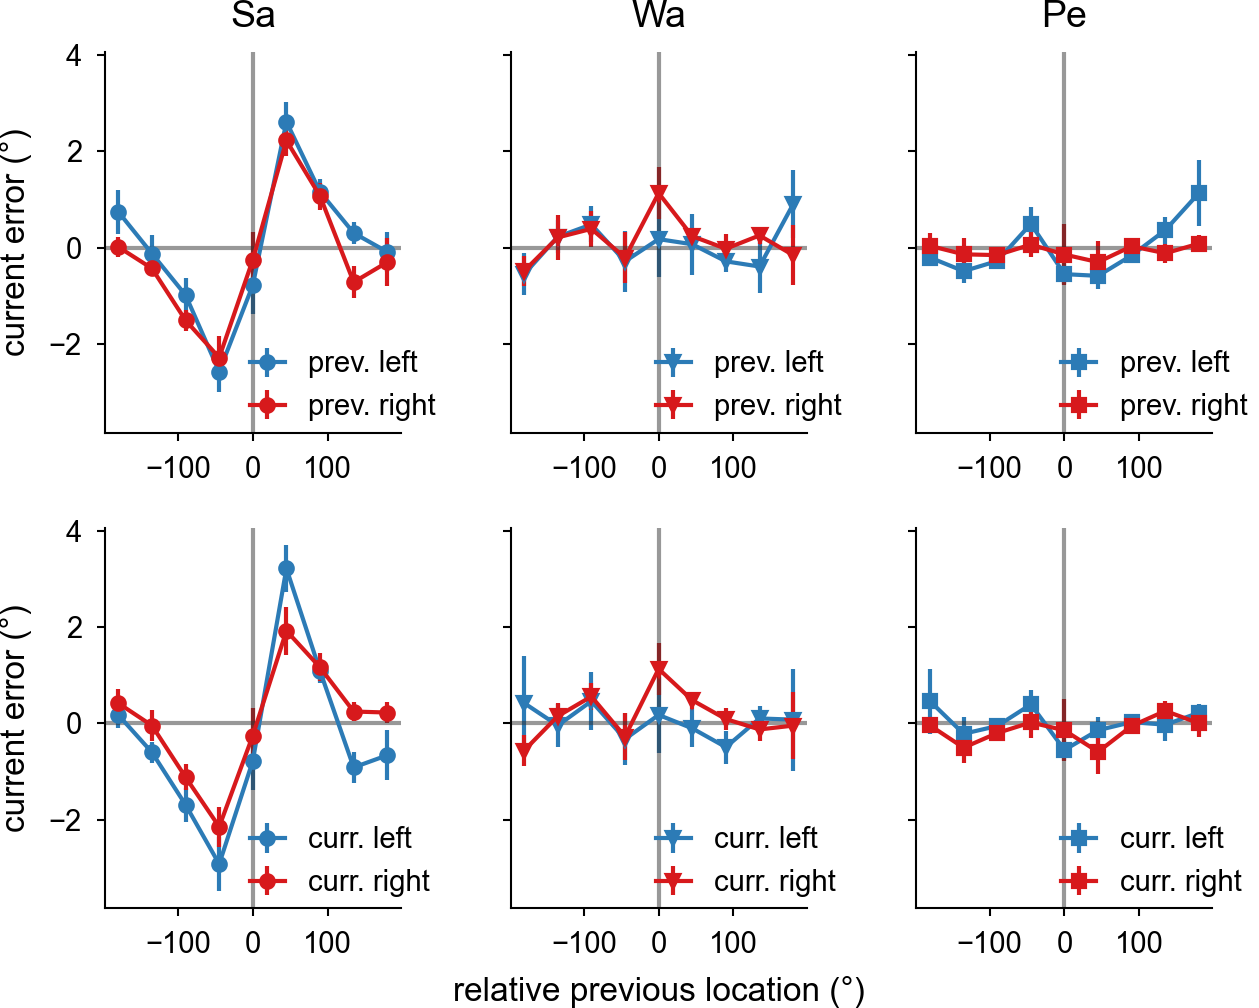

In [31]:
targets = np.unique(df_sb.loc[df_sb.session_continuous=='Sa0'].rel_loc)
markers = ['o', 'v', 's']


fig,ax = plt.subplots(2, 3,figsize=(4.5,3.6), sharey=True)
plt.subplots_adjust(wspace=0.5)

sess_continuous=0
DoG_left, DoG_right = [], []
for m,mono in enumerate(['Sa', 'Wa', 'Pe']): # enumerate(['Sa']):#
    df_mono = df_sb.loc[df_sb.monkey==mono].copy()
    sb_session_left, sb_session_left_curr = np.empty((len(np.unique(df_mono.session)),len(targets))), np.empty((len(np.unique(df_mono.session)),len(targets)))
    sb_session_right, sb_session_right_curr = np.empty((len(np.unique(df_mono.session)),len(targets))), np.empty((len(np.unique(df_mono.session)),len(targets)))
    for sess in np.unique(df_mono.session):
        df_sess = df_mono.loc[df_mono.session == sess]
        
        df_left = df_sess.loc[(df_sess.target_prev > -np.pi/2) & (df_sess.target_prev < np.pi/2)].copy()
        df_right = df_sess.loc[(df_sess.target_prev > np.pi/2) | (df_sess.target_prev < -np.pi/2)].copy()
        df_left_curr = df_sess.loc[(df_sess.target_curr > -np.pi/2) & (df_sess.target_curr < np.pi/2)].copy()
        df_right_curr = df_sess.loc[(df_sess.target_curr > np.pi/2) | (df_sess.target_curr < -np.pi/2)].copy()
        for t_id,t in enumerate(targets):
            sb_session_left[int(sess),t_id] = circmean(df_left.loc[df_left.rel_loc==t].err, low=-np.pi, high=np.pi)
            sb_session_right[int(sess),t_id] = circmean(df_right.loc[df_right.rel_loc==t].err, low=-np.pi, high=np.pi)
            sb_session_left_curr[int(sess),t_id] = circmean(df_left_curr.loc[df_left_curr.rel_loc==t].err, low=-np.pi, high=np.pi)
            sb_session_right_curr[int(sess),t_id] = circmean(df_right_curr.loc[df_right_curr.rel_loc==t].err, low=-np.pi, high=np.pi)
            
        sess_continuous += 1
        
        # fit model
#         df_left = df_mono.loc[(df_mono.target_prev > -np.pi/2) & (df_mono.target_prev < np.pi/2)].copy()
#         df_right = df_mono.loc[(df_mono.target_prev > np.pi/2) | (df_mono.target_prev < -np.pi/2)].copy()

        df_left['DoG_fit'] = -hf.dog1(sigma[mono],df_left.rel_loc)
        M_left = smf.ols(formula='err~DoG_fit', data=df_left).fit()
        DoG_left.append(np.rad2deg(M_left.params['DoG_fit']))

        df_right['DoG_fit'] = -hf.dog1(sigma[mono],df_right.rel_loc)
        M_right = smf.ols(formula='err~DoG_fit', data=df_right).fit()
        DoG_right.append(np.rad2deg(M_right.params['DoG_fit']))

    ax[0][m].axhline(color='#333333', alpha=0.5, linewidth=1)
    ax[0][m].axvline(color='#333333', alpha=0.5, linewidth=1)
    ax[0][m].errorbar(np.rad2deg(targets),np.rad2deg(np.nanmean(sb_session_left, axis=0)),\
                   yerr = np.rad2deg(sem(sb_session_left, axis=0, nan_policy='omit')),\
                color=colors['Left'], marker=markers[m], label='prev. left')
    ax[0][m].errorbar(np.rad2deg(targets),np.rad2deg(np.nanmean(sb_session_right, axis=0)),\
                   yerr = np.rad2deg(sem(sb_session_right, axis=0, nan_policy='omit')),\
                color=colors['Right'], marker=markers[m], label='prev. right')
    
    ax[1][m].axhline(color='#333333', alpha=0.5, linewidth=1)
    ax[1][m].axvline(color='#333333', alpha=0.5, linewidth=1)
    ax[1][m].errorbar(np.rad2deg(targets),np.rad2deg(np.nanmean(sb_session_left_curr, axis=0)),\
                   yerr = np.rad2deg(sem(sb_session_left_curr, axis=0, nan_policy='omit')),\
                color=colors['Left'], marker=markers[m], label='curr. left')
    ax[1][m].errorbar(np.rad2deg(targets),np.rad2deg(np.nanmean(sb_session_right_curr, axis=0)),\
                   yerr = np.rad2deg(sem(sb_session_right_curr, axis=0, nan_policy='omit')),\
                color=colors['Right'], marker=markers[m], label='curr. right')


    ax[0][m].set_title(mono)
    ax[0][m].legend(loc=(0.45,0), handlelength=1.2)
    ax[1][m].legend(loc=(0.45,0), handlelength=1.2)
ax[0][0].set_ylabel('current error (°)')
ax[1][0].set_ylabel('current error (°)')
ax[1][1].set_xlabel('relative previous location (°)')
plt.tight_layout()
#plt.savefig(DATAPATH+'/Figures/Paper/Behavior/Supplement_LeftRightSD.svg', bbox_inches='tight', pad_inches=0)
plt.show()

